In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("COMPANY BANKRUPTCY PREDICTION.csv")

BASIC INFORMATION ABOUT **DATASET**

In [3]:
df.shape

(6819, 96)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [5]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [6]:
df.isnull().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

In [7]:
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [8]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


# **EDA**

In [9]:
target_col = "Bankrupt?"
class_counts = df[target_col].value_counts()
print(class_counts)

class_percentage = df[target_col].value_counts(normalize=True)*100
print("class %age",class_percentage)

Bankrupt?
0    6599
1     220
Name: count, dtype: int64
class %age Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


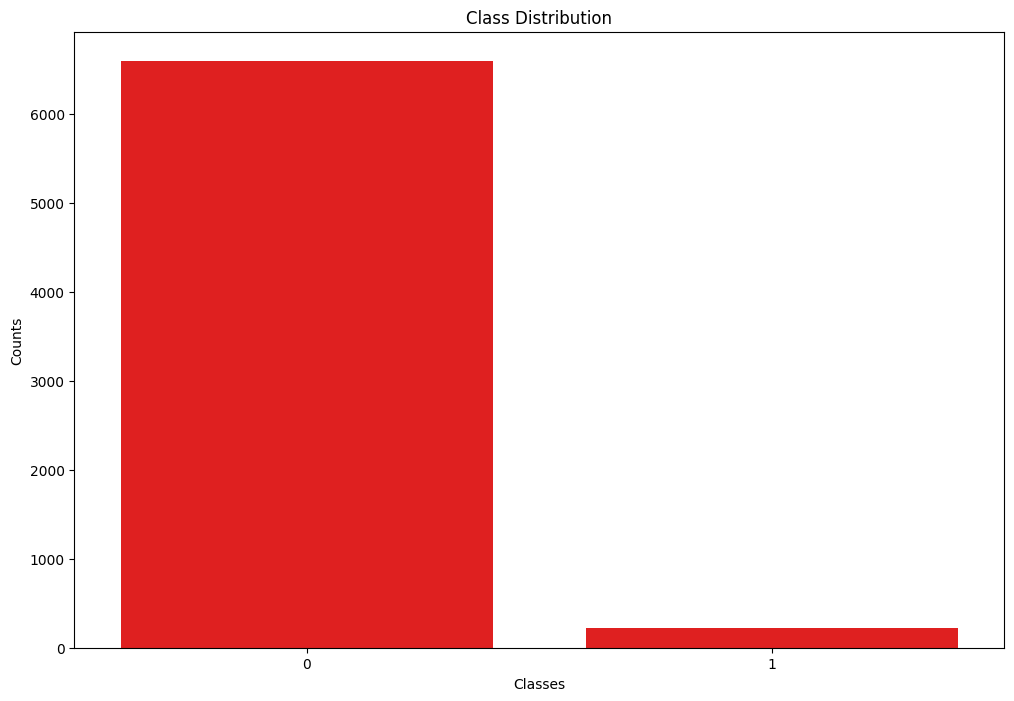

In [10]:
#Class Distribution

plt.figure(figsize=(12,8))
sns.countplot(x=df[target_col],color="red")
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Counts")
plt.show()

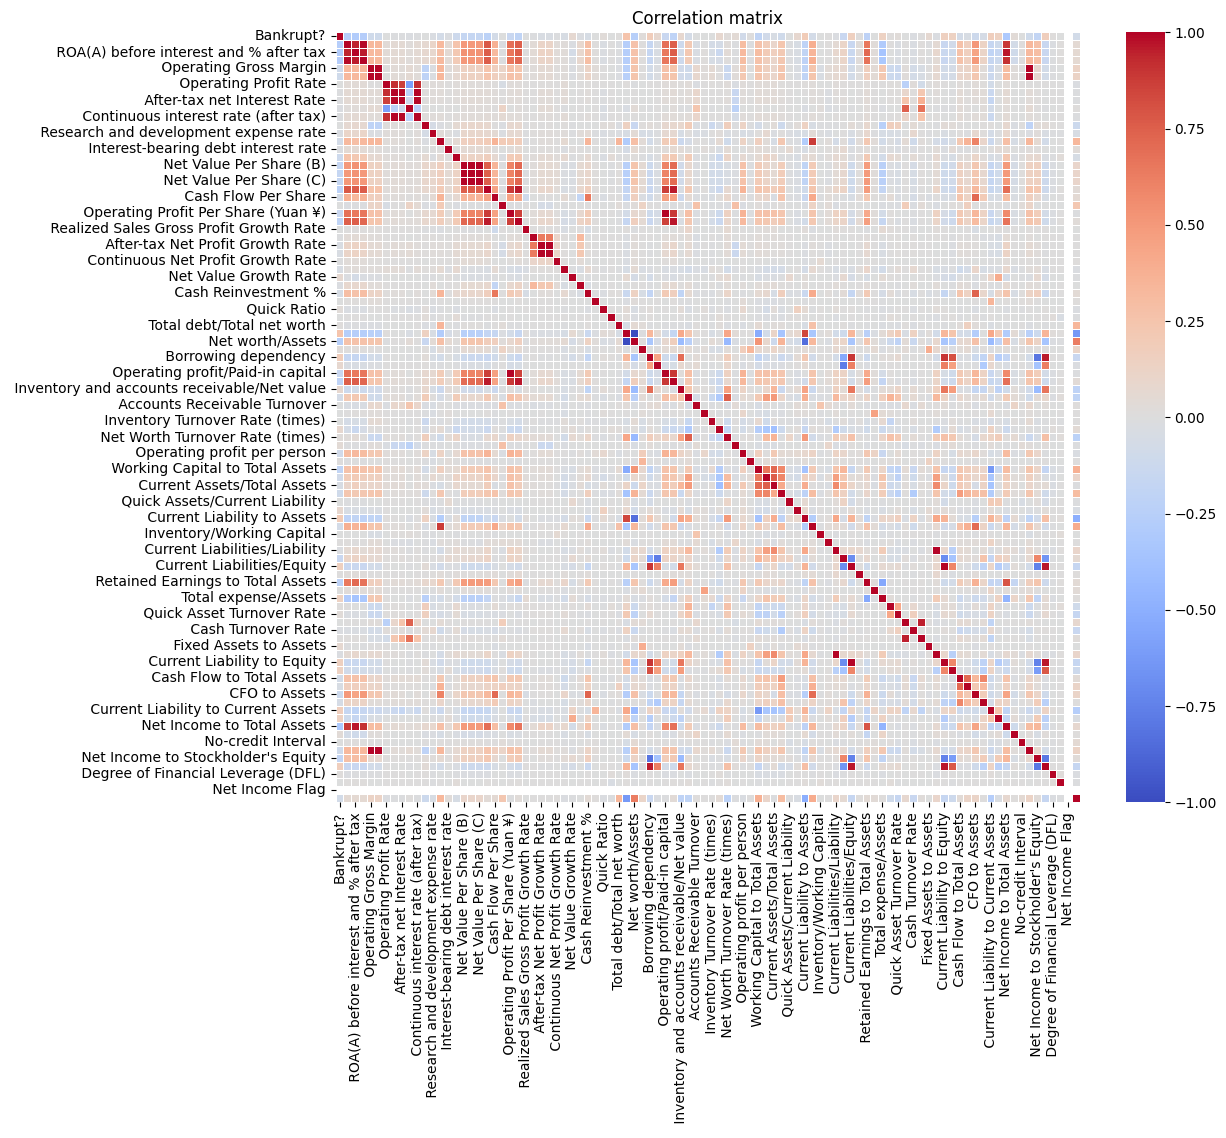

In [11]:
#Correlation Matrix

corr_matrix = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,cmap="coolwarm",linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

In [12]:
target_corr = corr_matrix[target_col].sort_values(ascending=False)

top_features = target_corr[1:11]
bottom_features = target_corr[-10:]

print("Top features are :",top_features)
print("\n")
print("Bottom features are:",bottom_features)

Top features are : Debt ratio %                           0.250161
Current Liability to Assets            0.194494
Borrowing dependency                   0.176543
Current Liability to Current Assets    0.171306
Liability to Equity                    0.166812
Current Liabilities/Equity             0.153828
Current Liability to Equity            0.153828
Liability-Assets Flag                  0.139212
Total expense/Assets                   0.139049
Equity to Long-term Liability          0.139014
Name: Bankrupt?, dtype: float64


Bottom features are: Per Share Net profit before tax (Yuan ¥)                  -0.201395
Net profit before tax/Paid-in capital                     -0.207857
Retained Earnings to Total Assets                         -0.217779
Persistent EPS in the Last Four Seasons                   -0.219560
Net worth/Assets                                          -0.250161
ROA(C) before interest and depreciation before interest   -0.260807
ROA(B) before interest and depreciatio

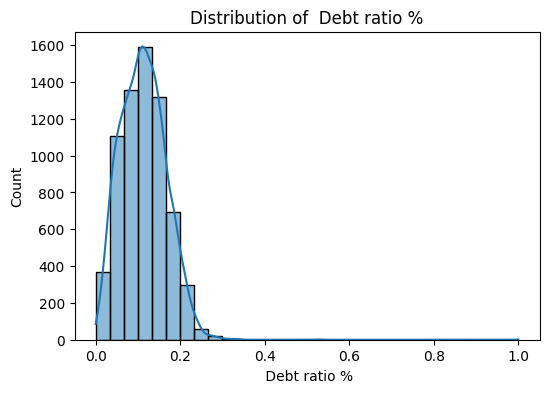

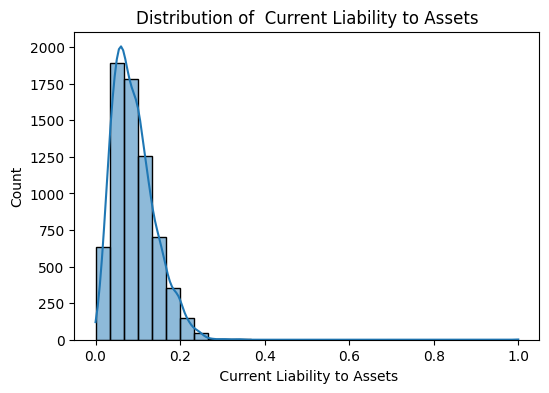

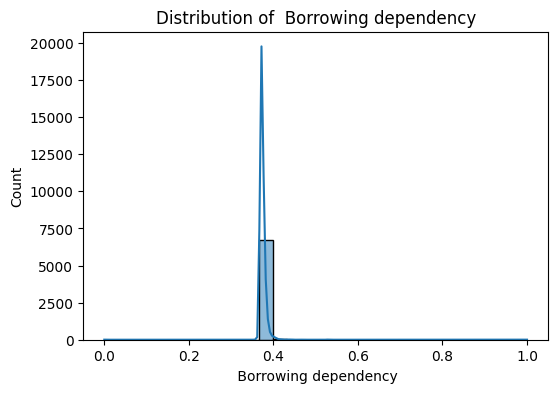

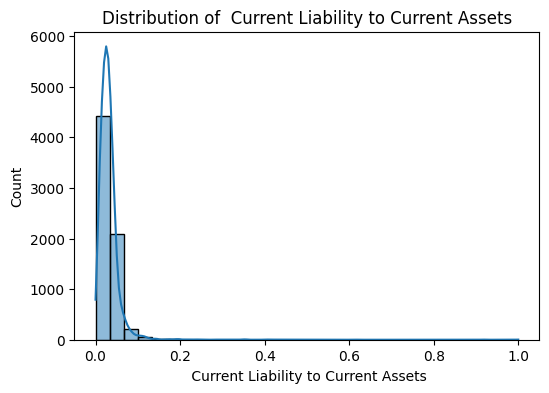

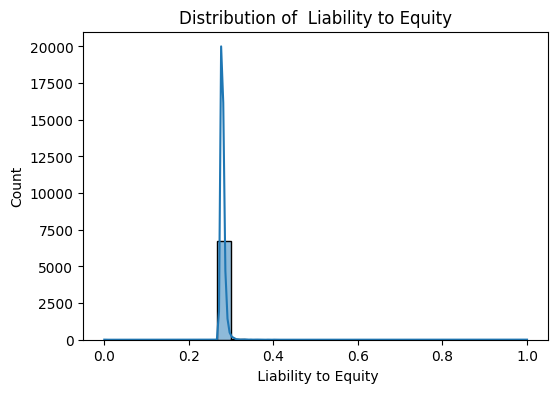

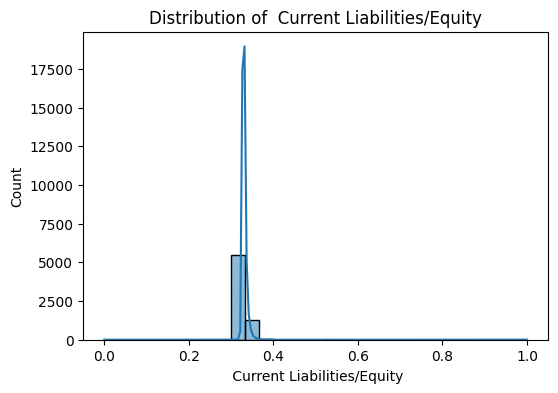

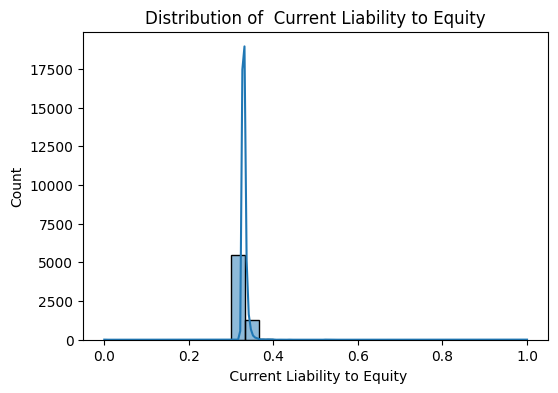

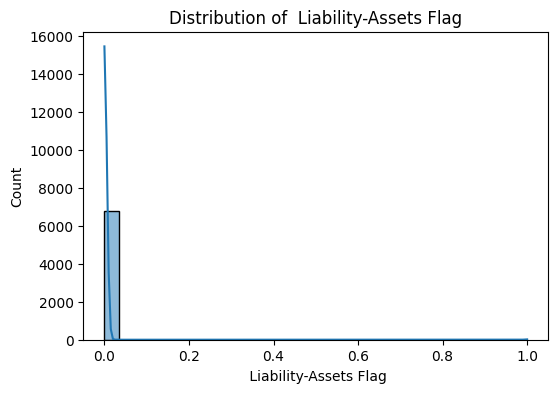

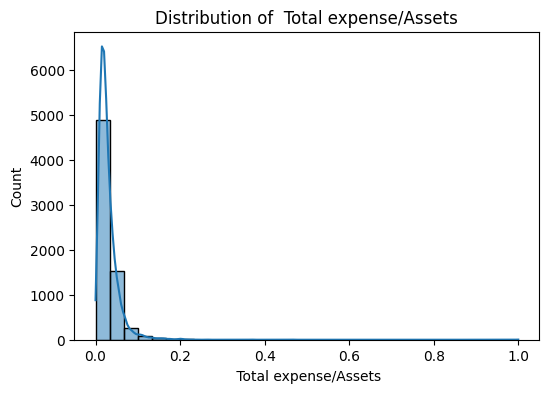

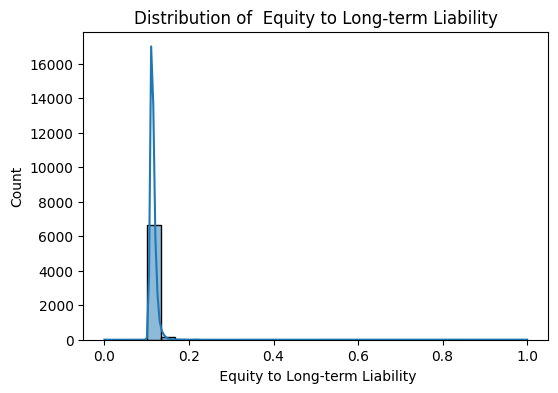

In [13]:
selected_features = list(top_features.index[:10])

for features in selected_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[features], kde=True, bins=30)
    plt.title(f"Distribution of {features}")
    plt.show()

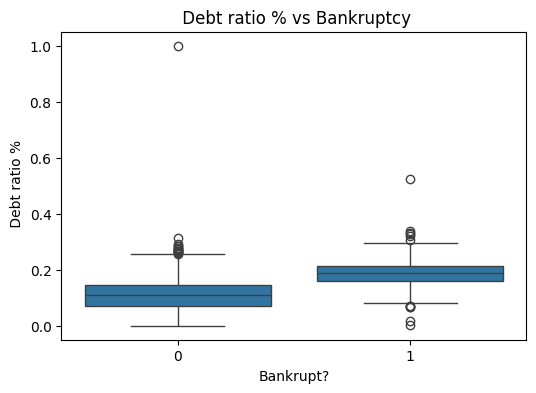

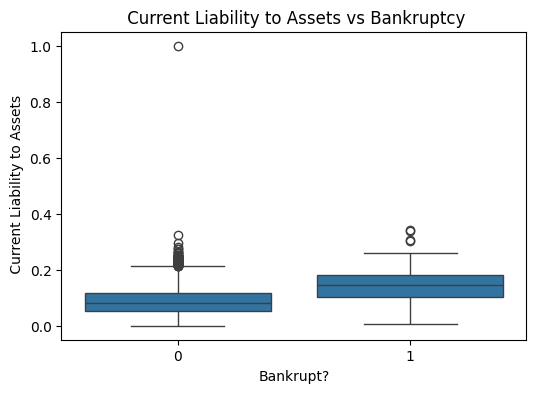

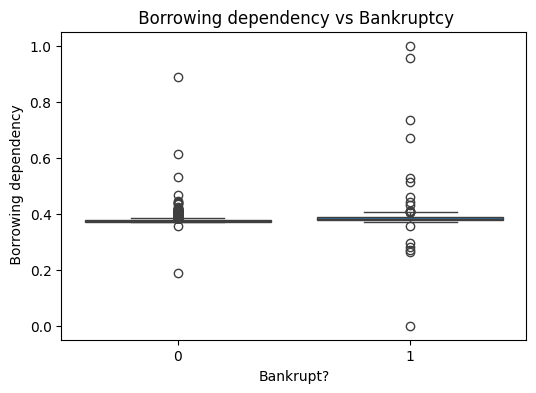

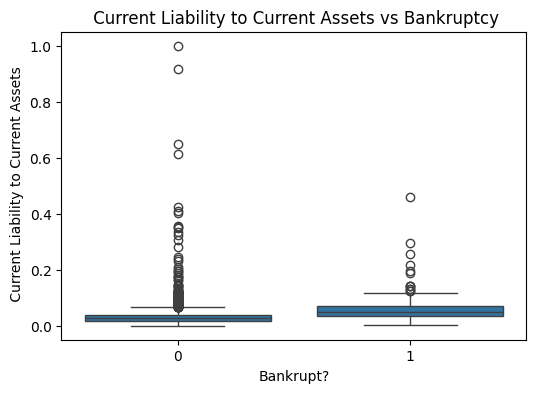

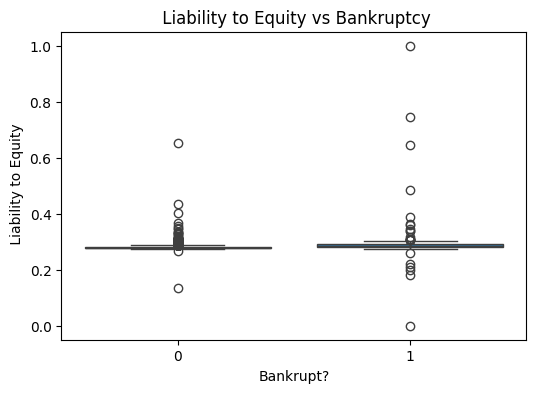

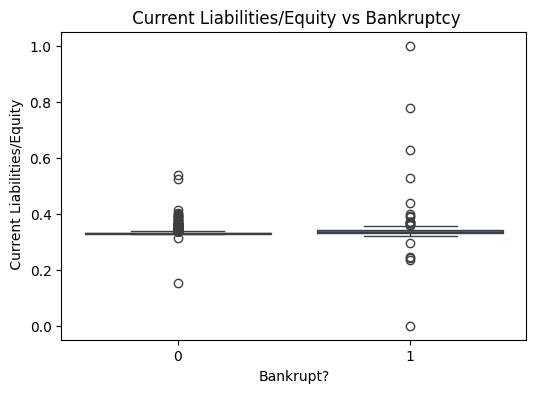

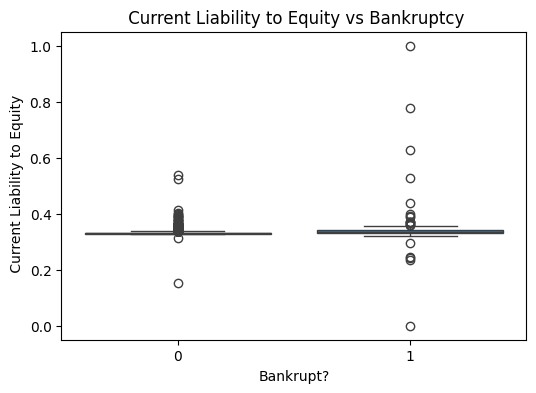

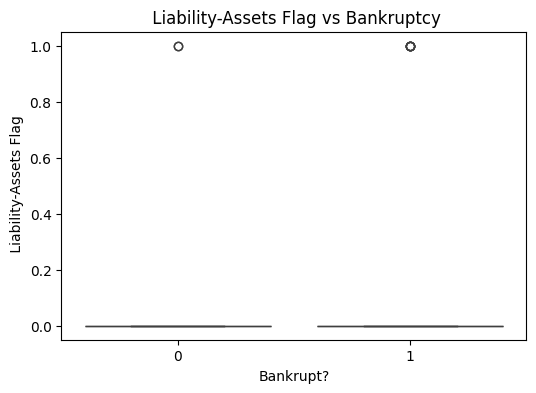

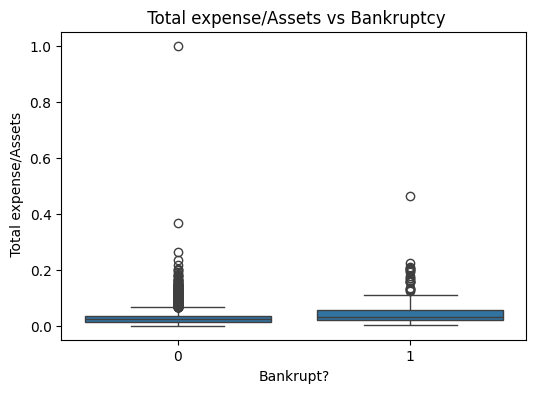

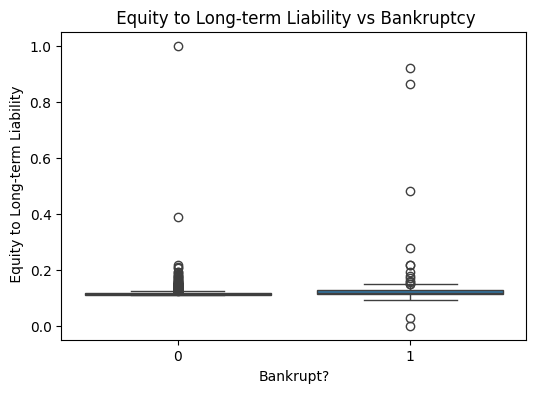

In [14]:
for features in selected_features:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[target_col],y=df[features])
  plt.title(f"{features} vs Bankruptcy")
  plt.show()

# **Data Preprocesssing**

In [16]:
pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from collections import Counter

In [18]:
X=df.drop(columns=[target_col])
y=df[target_col]

print("Features shapes:",X.shape)
print("Target shape:",y.shape)

Features shapes: (6819, 95)
Target shape: (6819,)


In [19]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Before SMOTE: Counter({0: 5286, 1: 169})
After SMOTE: Counter({0: 5286, 1: 5286})


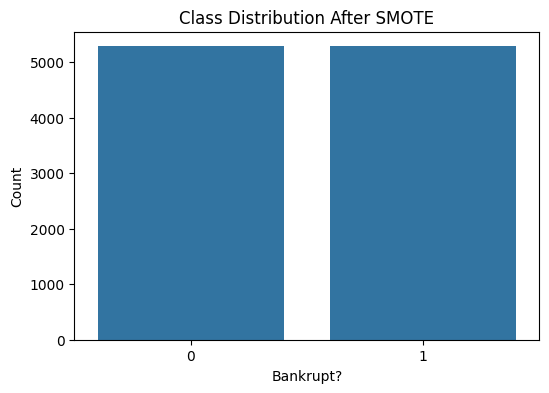

In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.show()

## Data Preprocessing

- Performed stratified train-test split to preserve class distribution
- Applied feature scaling using StandardScaler
- Addressed severe class imbalance using SMOTE (Synthetic Minority Oversampling Technique)

## Why SMOTE?

- Original dataset had very few bankruptcy cases (~3%)
- Models trained on such data tend to ignore minority class
- SMOTE generates synthetic samples to balance the dataset

## Result

- Balanced training dataset achieved
- Improved ability to detect bankrupt companies (minority class)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, class_weight='balanced')
}

In [24]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print("-"*40)
    print(classification_report(y_test, y_pred))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    }

In [25]:
results = []

for name, model in models.items():
    result = evaluate_model(
        name,
        model,
        X_train_smote, y_train_smote,
        X_test_scaled, y_test
    )
    results.append(result)


Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1313
           1       0.18      0.71      0.29        51

    accuracy                           0.87      1364
   macro avg       0.59      0.79      0.61      1364
weighted avg       0.96      0.87      0.91      1364


Decision Tree
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1313
           1       0.28      0.51      0.36        51

    accuracy                           0.93      1364
   macro avg       0.63      0.73      0.66      1364
weighted avg       0.95      0.93      0.94      1364


Random Forest
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1313
           1       0.40      0.53      0.45        51

    accu

In [27]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.952346,0.397059,0.529412,0.453782,0.927400
0,Logistic Regression,0.872434,0.184615,0.705882,0.292683,0.918298
4,SVM,0.882698,0.188571,0.647059,0.292035,0.906904
3,Gradient Boosting,0.928152,0.284404,0.607843,0.387500,0.894628
1,Decision Tree,0.933284,0.282609,0.509804,0.363636,0.729769


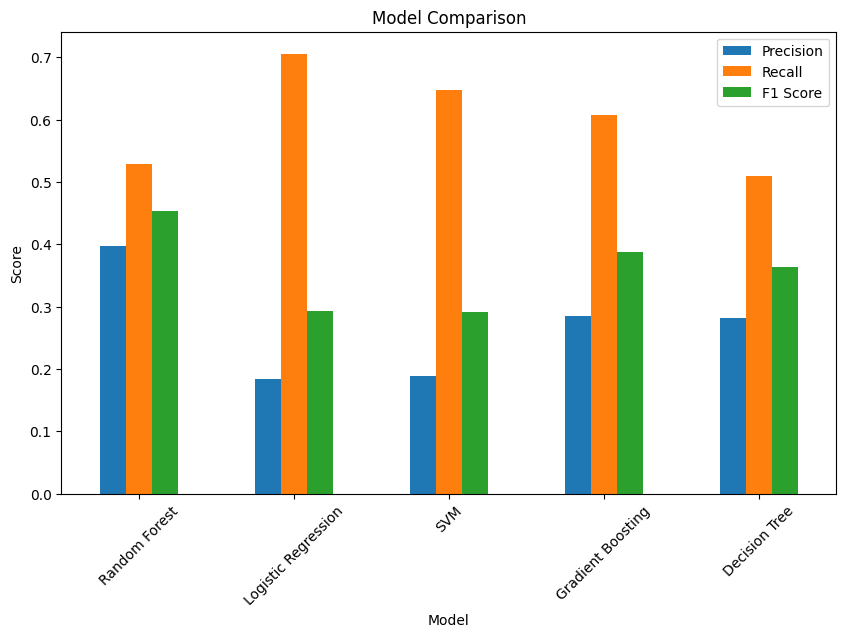

In [28]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(
    kind='bar', figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [29]:
import os

os.makedirs("model", exist_ok=True)

In [30]:
best_model = models["Random Forest"]

In [31]:
import joblib


joblib.dump(best_model, "model/model.pkl")


joblib.dump(scaler, "model/scaler.pkl")


try:
    feature_list = selected_features.tolist()
except:
    feature_list = X.columns.tolist()

joblib.dump(feature_list, "model/features.pkl")

print("✅ Model, scaler, and features saved successfully!")

✅ Model, scaler, and features saved successfully!
